<a href="https://colab.research.google.com/github/itsFr4nc0/red-neuronal-creditos/blob/main/Modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# ── Reproducibilidad ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Seeds fijados: SEED = {SEED}")

Seeds fijados: SEED = 42


In [3]:
df = pd.read_csv("./data/loan.csv", low_memory=False)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           887379 non-null  int64  
 1   member_id                    887379 non-null  int64  
 2   loan_amnt                    887379 non-null  float64
 3   funded_amnt                  887379 non-null  float64
 4   funded_amnt_inv              887379 non-null  float64
 5   term                         887379 non-null  object 
 6   int_rate                     887379 non-null  float64
 7   installment                  887379 non-null  float64
 8   grade                        887379 non-null  object 
 9   sub_grade                    887379 non-null  object 
 10  emp_title                    835917 non-null  object 
 11  emp_length                   842554 non-null  object 
 12  home_ownership               887379 non-null  object 
 13 

In [5]:
cols_to_drop = [
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_amnt",
    "out_prncp",
    "out_prncp_inv"
]

cols_drop_extra = [
    "id",
    "member_id",
    "url",
    "desc",
    "title",
    "issue_d"
]

In [6]:
# eliminar leakage
df = df.drop(columns=cols_to_drop)

# eliminar extras
df = df.drop(columns=cols_drop_extra)

# eliminar columnas con muchos nulos
threshold = 0.1 * len(df)
df = df.dropna(thresh=threshold, axis=1)

In [7]:
df["term"] = df["term"].str.extract(r"(\d+)").astype(float)

In [8]:
df["emp_length"] = df["emp_length"].str.extract(r"(\d+)")
df["emp_length"] = pd.to_numeric(df["emp_length"], errors="coerce")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    887379 non-null  float64
 1   funded_amnt                  887379 non-null  float64
 2   funded_amnt_inv              887379 non-null  float64
 3   term                         887379 non-null  float64
 4   int_rate                     887379 non-null  float64
 5   installment                  887379 non-null  float64
 6   grade                        887379 non-null  object 
 7   sub_grade                    887379 non-null  object 
 8   emp_title                    835917 non-null  object 
 9   emp_length                   842554 non-null  float64
 10  home_ownership               887379 non-null  object 
 11  annual_inc                   887375 non-null  float64
 12  verification_status          887379 non-null  object 
 13 

In [10]:
print(df["loan_status"].unique())

['Fully Paid' 'Charged Off' 'Current' 'Default' 'Late (31-120 days)'
 'In Grace Period' 'Late (16-30 days)'
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off' 'Issued']


In [11]:
def map_loan_status(status):
    if status in ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]:
        return 0
    elif status in ["Charged Off", "Default", "Late (31-120 days)",
                    "Does not meet the credit policy. Status:Charged Off"]:
        return 1
    else:
        return np.nan

df["target"] = df["loan_status"].apply(map_loan_status)

df = df.dropna(subset=["target"])

In [12]:
df = df.drop(columns=["loan_status"])

In [13]:
cols_leakage = [
    "last_pymnt_d",
    "next_pymnt_d",
    "last_credit_pull_d"
]

cols_text = [
    "emp_title",
    "zip_code"
]

In [14]:
df = df.drop(columns=cols_leakage + cols_text + ["earliest_cr_line"])

In [15]:
for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna("Unknown")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268530 entries, 0 to 887371
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    268530 non-null  float64
 1   funded_amnt                  268530 non-null  float64
 2   funded_amnt_inv              268530 non-null  float64
 3   term                         268530 non-null  float64
 4   int_rate                     268530 non-null  float64
 5   installment                  268530 non-null  float64
 6   grade                        268530 non-null  object 
 7   sub_grade                    268530 non-null  object 
 8   emp_length                   268530 non-null  float64
 9   home_ownership               268530 non-null  object 
 10  annual_inc                   268530 non-null  float64
 11  verification_status          268530 non-null  object 
 12  pymnt_plan                   268530 non-null  object 
 13  purp

In [17]:
X = df.drop(columns=["target"])
y = df["target"]

In [18]:
num_cols = X.select_dtypes(include=["float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [19]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [20]:
from sklearn.model_selection import train_test_split

# Split 70% train / 15% val / 15% test (estratificado)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train: 187,971 | Val: 40,279 | Test: 40,280


In [21]:
X_train = preprocessor.fit_transform(X_train)
X_val   = preprocessor.transform(X_val)
X_test  = preprocessor.transform(X_test)

In [22]:
X_train = X_train.toarray()
X_val   = X_val.toarray()
X_test  = X_test.toarray()

In [23]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val,   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test.values,  dtype=torch.float32).view(-1, 1)

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

X_train_tensor = X_train_tensor.to(device)
X_val_tensor   = X_val_tensor.to(device)
X_test_tensor  = X_test_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
y_val_tensor   = y_val_tensor.to(device)
y_test_tensor  = y_test_tensor.to(device)

# ── DataLoaders con mini-batches ─────────────────────────────────────────────
BATCH_SIZE = 512

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches train: {len(train_loader)} | Batches val: {len(val_loader)}")

Usando dispositivo: cpu
Batches train: 368 | Batches val: 79


In [25]:
class RedRiesgo(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            # Bloque 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Bloque 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Bloque 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

In [26]:
input_dim = X_train_tensor.shape[1]

model = RedRiesgo(input_dim).to(device)

# Peso de clase para manejar el desbalance (buenos pagadores >> malos)
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"pos_weight (desbalance): {pos_weight:.2f}")

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32).to(device)
)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Reduce LR x10 si val_loss no mejora en 5 épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=7
)

pos_weight (desbalance): 3.57


Epoch  10 | train_loss: 0.9560 | val_loss: 0.9649 | lr: 1.00e-03 | patience: 0/15
Epoch  20 | train_loss: 0.9341 | val_loss: 0.9710 | lr: 1.00e-04 | patience: 10/15
Epoch  25 | train_loss: 0.9293 | val_loss: 0.9733 | lr: 1.00e-04 | patience: 15/15

Early stopping en época 25. Mejor val_loss: 0.9649


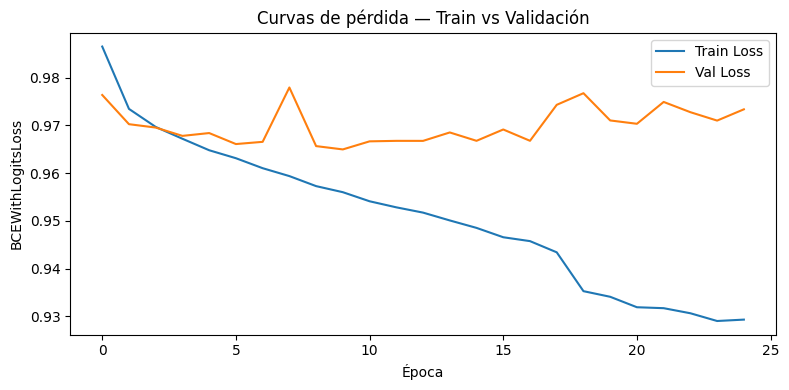

In [27]:
EPOCHS        = 150
PATIENCE      = 15   # early stopping: épocas sin mejora en val_loss
BEST_VAL_LOSS = float('inf')
patience_counter = 0

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Entrenamiento ───────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # ── Validación ──────────────────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_running_loss += loss.item() * X_batch.size(0)
    val_loss = val_running_loss / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # ── Scheduler ───────────────────────────────────────────────────────────
    scheduler.step(val_loss)

    # ── Guardar mejor modelo + Early Stopping ────────────────────────────────
    if val_loss < BEST_VAL_LOSS:
        BEST_VAL_LOSS = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1

    if epoch % 10 == 0 or patience_counter == PATIENCE:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d} | train_loss: {train_loss:.4f} | "
              f"val_loss: {val_loss:.4f} | lr: {lr_now:.2e} | patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping en época {epoch}. Mejor val_loss: {BEST_VAL_LOSS:.4f}")
        break

# ── Curva de pérdida ─────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Época')
plt.ylabel('BCEWithLogitsLoss')
plt.title('Curvas de pérdida — Train vs Validación')
plt.legend()
plt.tight_layout()
plt.savefig('curva_perdida.png', dpi=150)
plt.show()

═══════════════════════════════════════════════════════
  EVALUACIÓN — Red Neuronal (mejor modelo)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

         0.0     0.8751    0.6403    0.7395     31457
         1.0     0.3446    0.6743    0.4561      8823

    accuracy                         0.6477     40280
   macro avg     0.6099    0.6573    0.5978     40280
weighted avg     0.7589    0.6477    0.6774     40280

AUC-ROC Red Neuronal: 0.7160

═══════════════════════════════════════════════════════
  BASELINE — Regresión Logística
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

         0.0     0.8725    0.6366    0.7361     31457
         1.0     0.3403    0.6683    0.4509      8823

    accuracy                         0.6435     40280
   macro avg     0.6064    0.6524    0.5935     40280
weighted avg     0.7559    0.6435    0.6736     40280

AUC-ROC Regresió

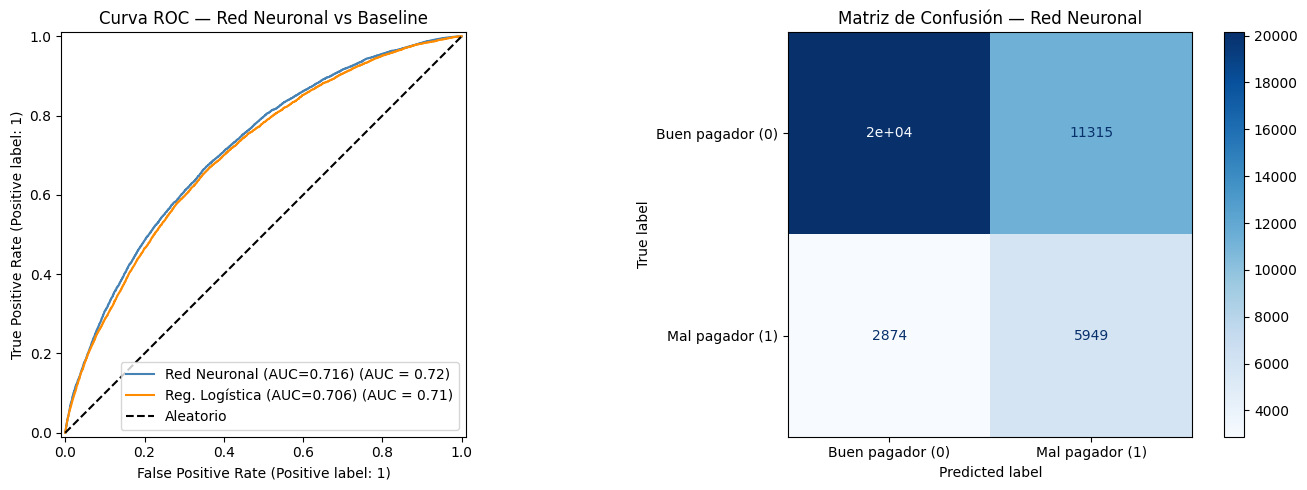


Mejora sobre baseline: +1.02 puntos AUC


In [28]:
# ── Cargar el mejor modelo guardado ──────────────────────────────────────────
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

with torch.no_grad():
    logits = model(X_test_tensor)
    probs  = torch.sigmoid(logits)
    y_pred = (probs > 0.5).float()

y_test_np  = y_test_tensor.cpu().numpy().ravel()
probs_np   = probs.cpu().numpy().ravel()
y_pred_np  = y_pred.cpu().numpy().ravel()

print("═" * 55)
print("  EVALUACIÓN — Red Neuronal (mejor modelo)")
print("═" * 55)
print(classification_report(y_test_np, y_pred_np, digits=4))
auc_nn = roc_auc_score(y_test_np, probs_np)
print(f"AUC-ROC Red Neuronal: {auc_nn:.4f}")

# ── Baseline: Regresión Logística ─────────────────────────────────────────────
print("\n" + "═" * 55)
print("  BASELINE — Regresión Logística")
print("═" * 55)
X_train_np = X_train_tensor.cpu().numpy()
X_test_np  = X_test_tensor.cpu().numpy()
y_train_np = y_train_tensor.cpu().numpy().ravel()

lr_baseline = LogisticRegression(max_iter=1000, random_state=SEED,
                                  class_weight='balanced')
lr_baseline.fit(X_train_np, y_train_np)
lr_probs = lr_baseline.predict_proba(X_test_np)[:, 1]
lr_preds = (lr_probs >= 0.5).astype(float)
auc_lr   = roc_auc_score(y_test_np, lr_probs)
print(classification_report(y_test_np, lr_preds, digits=4))
print(f"AUC-ROC Regresión Logística: {auc_lr:.4f}")

# ── Curva ROC comparativa ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test_np, probs_np,
    name=f"Red Neuronal (AUC={auc_nn:.3f})",
    ax=axes[0], color='steelblue'
)
RocCurveDisplay.from_predictions(
    y_test_np, lr_probs,
    name=f"Reg. Logística (AUC={auc_lr:.3f})",
    ax=axes[0], color='darkorange'
)
axes[0].plot([0,1],[0,1],'k--', label='Aleatorio')
axes[0].set_title('Curva ROC — Red Neuronal vs Baseline')
axes[0].legend()

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test_np, y_pred_np,
    display_labels=['Buen pagador (0)', 'Mal pagador (1)'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Matriz de Confusión — Red Neuronal')

plt.tight_layout()
plt.savefig('evaluacion_modelo.png', dpi=150)
plt.show()

print(f"\nMejora sobre baseline: {(auc_nn - auc_lr)*100:+.2f} puntos AUC")

## 📋 Scorecard — Conversión de Probabilidad a Score Crediticio

Transformamos la probabilidad de default en un puntaje entero (escala 300–850).

**Fórmula estándar de la industria:**
$$\text{Score} = 600 - 50 \cdot \ln\left(\frac{p}{1-p}\right)$$

- Score **alto** → bajo riesgo de impago  
- Score **bajo** → alto riesgo de impago  
- Score = 600 cuando p = 50% (umbral de indiferencia)

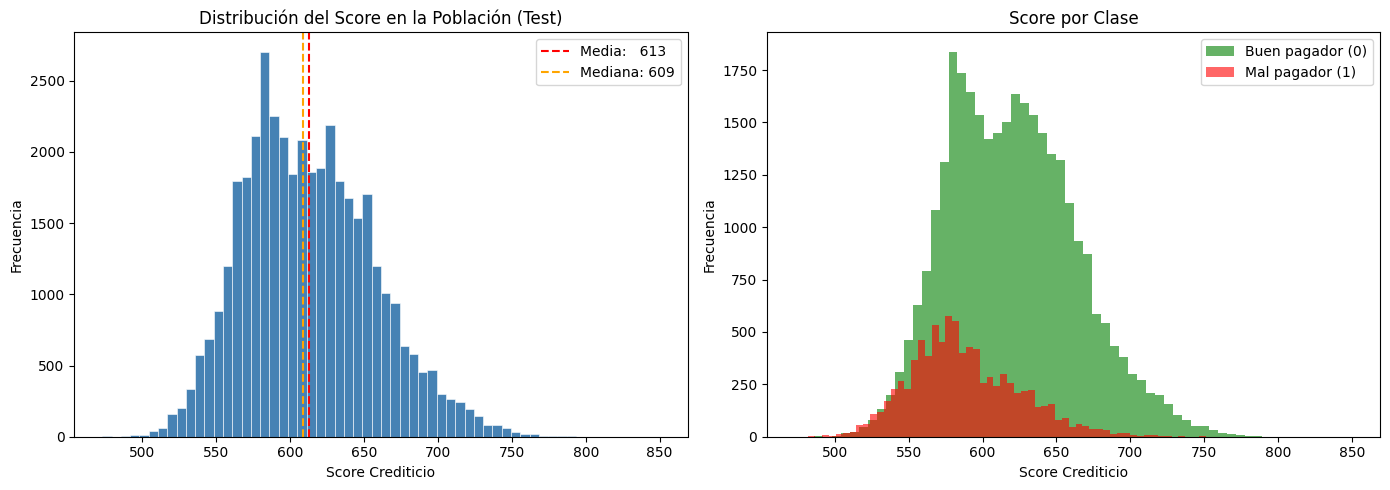


  BANDAS DE RIESGO  —  40,280 registros del conjunto de test
  Banda                Score               N        %   Tasa default
  ------------------------------------------------------------
  🟢 Muy Bajo Riesgo    700-850        1,467     3.6%          2.7%
  🟡 Bajo Riesgo        600-699       21,549    53.5%         13.2%
  🟠 Riesgo Moderado    500-599       17,247    42.8%         34.4%
  🔴 Alto Riesgo        400-499           17     0.0%         76.5%
  ⛔ Muy Alto Riesgo    300-399            0     0.0%          0.0%

Score promedio: 612.8 | Mediana: 609.0 | Std: 44.1


In [37]:
# ── Scorecard: p → score (escala 300–850) ────────────────────────────────────
model.eval()
with torch.no_grad():
    logits_test = model(X_test_tensor).cpu().numpy().flatten()

p_default = 1 / (1 + np.exp(-logits_test))        # probabilidad de default
p_default = np.clip(p_default, 1e-6, 1 - 1e-6)    # evitar log(0)
odds  = p_default / (1 - p_default)
scores = (600 - 50 * np.log(odds)).clip(300, 850).astype(int)

# ── Distribución del score ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(scores, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(scores.mean(),      color='red',    linestyle='--', label=f'Media:   {scores.mean():.0f}')
axes[0].axvline(np.median(scores),  color='orange', linestyle='--', label=f'Mediana: {np.median(scores):.0f}')
axes[0].set_xlabel('Score Crediticio')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Score en la Población (Test)')
axes[0].legend()

axes[1].hist(scores[y_test.values == 0], bins=60, alpha=0.6, color='green', label='Buen pagador (0)')
axes[1].hist(scores[y_test.values == 1], bins=60, alpha=0.6, color='red',   label='Mal pagador (1)')
axes[1].set_xlabel('Score Crediticio')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Score por Clase')
axes[1].legend()

plt.tight_layout()
plt.savefig('scorecard_distribucion.png', dpi=150)
plt.show()

# ── Tabla de bandas de riesgo ─────────────────────────────────────────────────
bands = [
    (700, 850, 'Muy Bajo Riesgo',  '🟢'),
    (600, 699, 'Bajo Riesgo',      '🟡'),
    (500, 599, 'Riesgo Moderado',  '🟠'),
    (400, 499, 'Alto Riesgo',      '🔴'),
    (300, 399, 'Muy Alto Riesgo',  '⛔'),
]
print(f"\n{'='*65}")
print(f"  BANDAS DE RIESGO  —  {len(scores):,} registros del conjunto de test")
print(f"{'='*65}")
print(f"  {'Banda':<20} {'Score':<12} {'N':>8}  {'%':>7}  {'Tasa default':>13}")
print(f"  {'-'*60}")
for lo, hi, label, icon in bands:
    mask  = (scores >= lo) & (scores <= hi)
    count = mask.sum()
    pct   = count / len(scores) * 100
    tasa  = y_test.values[mask].mean() * 100 if count > 0 else 0.0
    print(f"  {icon} {label:<18} {lo}-{hi:<7} {count:>8,}  {pct:>6.1f}%  {tasa:>11.1f}%")
print(f"{'='*65}")
print(f"\nScore promedio: {scores.mean():.1f} | Mediana: {np.median(scores):.1f} | Std: {scores.std():.1f}")

Calculando permutation importance sobre 5000 muestras x 147 features...
  Feature 20/147 procesada...
  Feature 40/147 procesada...
  Feature 60/147 procesada...
  Feature 80/147 procesada...
  Feature 100/147 procesada...
  Feature 120/147 procesada...
  Feature 140/147 procesada...


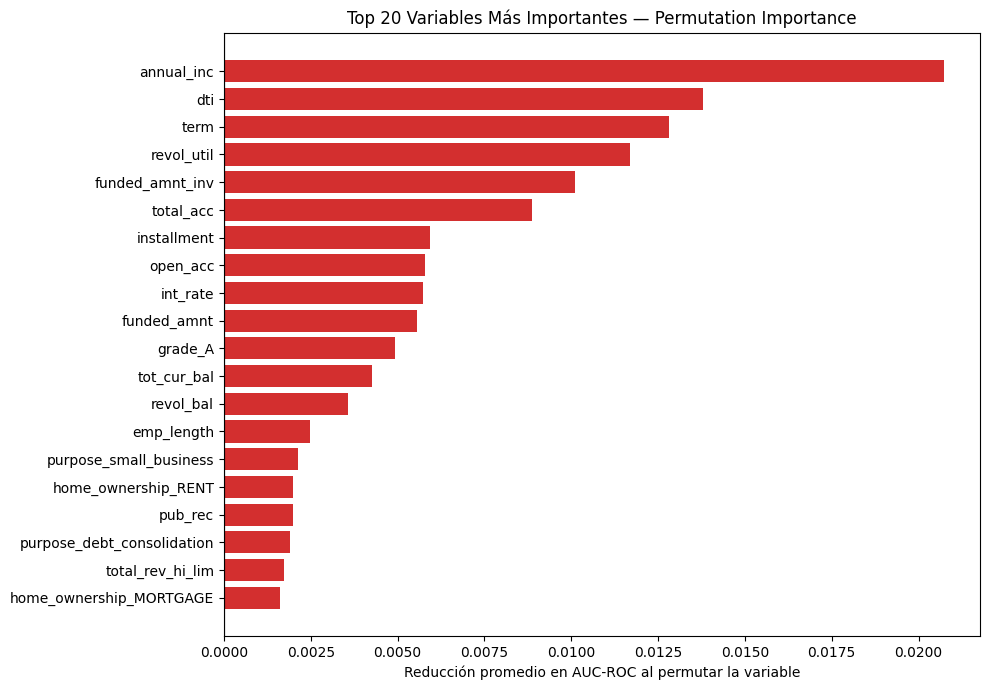


Top 10 variables más importantes:
   1. annual_inc                                ΔAUC: +0.02073
   2. dti                                       ΔAUC: +0.01380
   3. term                                      ΔAUC: +0.01283
   4. revol_util                                ΔAUC: +0.01169
   5. funded_amnt_inv                           ΔAUC: +0.01012
   6. total_acc                                 ΔAUC: +0.00888
   7. installment                               ΔAUC: +0.00593
   8. open_acc                                  ΔAUC: +0.00579
   9. int_rate                                  ΔAUC: +0.00572
  10. funded_amnt                               ΔAUC: +0.00555


In [38]:
# ── Importancia de Variables — Permutation Importance (manual) ───────────────
import joblib

def nn_predict_proba(X_np):
    """Devuelve probabilidades de default para un array numpy."""
    model.eval()
    with torch.no_grad():
        t = torch.tensor(X_np, dtype=torch.float32).to(device)
        logits = model(t).cpu().numpy().flatten()
    return 1 / (1 + np.exp(-logits))

def manual_permutation_importance(X, y, n_repeats=3, seed=42):
    """Calcula ΔAUC al permutar cada feature. Sin dependencias sklearn."""
    rng      = np.random.RandomState(seed)
    base_auc = roc_auc_score(y, nn_predict_proba(X))
    n_feat   = X.shape[1]
    imp      = np.zeros((n_feat, n_repeats))
    for i in range(n_feat):
        for r in range(n_repeats):
            X_perm      = X.copy()
            X_perm[:, i] = rng.permutation(X_perm[:, i])
            imp[i, r]   = base_auc - roc_auc_score(y, nn_predict_proba(X_perm))
        if (i + 1) % 20 == 0:
            print(f"  Feature {i+1}/{n_feat} procesada...")
    return imp.mean(axis=1), imp.std(axis=1)

# Muestra reducida para que sea manejable
N_SAMPLE = 5000
np.random.seed(SEED)
idx_sample = np.random.choice(len(X_test), N_SAMPLE, replace=False)
X_sample   = X_test[idx_sample]
y_sample   = y_test.values[idx_sample]

# Nombres de las features tras el preprocesamiento
num_feat = list(preprocessor.named_transformers_['num'].get_feature_names_out(num_cols))
cat_feat = list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))
all_feat = num_feat + cat_feat

print(f"Calculando permutation importance sobre {N_SAMPLE} muestras x {len(all_feat)} features...")
imp, imp_std = manual_permutation_importance(X_sample, y_sample, n_repeats=3, seed=SEED)

# ── Top 20 variables ─────────────────────────────────────────────────────────
top20 = np.argsort(imp)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d32f2f' if imp[i] > 0 else '#9e9e9e' for i in top20[::-1]]
ax.barh([all_feat[i] for i in top20[::-1]], imp[top20[::-1]], color=colors)
ax.set_xlabel('Reducción promedio en AUC-ROC al permutar la variable')
ax.set_title('Top 20 Variables Más Importantes — Permutation Importance')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150)
plt.show()

print("\nTop 10 variables más importantes:")
for rank, fi in enumerate(top20[:10], 1):
    print(f"  {rank:2}. {all_feat[fi]:<40}  ΔAUC: {imp[fi]:+.5f}")

In [39]:
# ── Guardar artefactos para la aplicación web ─────────────────────────────────
import os, shutil

os.makedirs('app', exist_ok=True)

joblib.dump(preprocessor, 'app/preprocessor.pkl')
print("✅  preprocessor guardado → app/preprocessor.pkl")

shutil.copy('best_model.pt', 'app/best_model.pt')
print("✅  modelo guardado       → app/best_model.pt")

meta = {
    'input_dim':    int(X_train_tensor.shape[1]),
    'num_cols':     list(num_cols),
    'cat_cols':     list(cat_cols),
    'score_mean':   float(scores.mean()),
    'score_std':    float(scores.std()),
    'score_median': float(np.median(scores)),
    'auc_nn':       float(auc_nn),
    'auc_lr':       float(auc_lr),
    'top_features': [all_feat[i] for i in top20[:10]] if 'top20' in dir() else [],
}
joblib.dump(meta, 'app/meta.pkl')
print("✅  metadatos guardados   → app/meta.pkl")

print("\nContenido de app/:")
for f in sorted(os.listdir('app')):
    size_kb = os.path.getsize(f'app/{f}') / 1024
    print(f"   {f:<30} {size_kb:>8.1f} KB")

✅  preprocessor guardado → app/preprocessor.pkl
✅  modelo guardado       → app/best_model.pt
✅  metadatos guardados   → app/meta.pkl

Contenido de app/:
   best_model.pt                     323.7 KB
   meta.pkl                            0.7 KB
   preprocessor.pkl                    8.8 KB
